## 1. Load dữ liệu và chuẩn bị features


# 05 — House Price Prediction (Sklearn)

## Mục tiêu
- Huấn luyện và so sánh 4 mô hình Regression: Linear Regression, Ridge, Random Forest, Gradient Boosting
- Đánh giá bằng MAE, RMSE, R² (trên cả log scale và giá thực)
- Phân tích Feature Importance
- Trực quan hóa Actual vs Predicted
- Lưu model tốt nhất


In [1]:
import pandas as pd

df = pd.read_parquet('../data/processed/data_modeling.parquet')

In [2]:
df.dtypes

giay_to_phap_ly       object
dien_tich            float64
gia_ban              float64
loai_hinh             object
so_phong_ngu           int64
quan                  object
gia_kv_hien_tai      float64
gia_kv_mean          float64
gia_kv_trend         float64
gia_kv_volatility    float64
full_text             object
is_mat_tien            int64
is_hxh                 int64
is_lo_goc              int64
is_kinh_doanh          int64
is_dong_tien           int64
is_no_hau              int64
has_thang_may          int64
is_nha_moi             int64
is_nha_nat             int64
has_quy_hoach          int64
is_chinh_chu           int64
has_san_thuong         int64
has_gara               int64
o_ngay                 int64
is_ngop_bank           int64
is_ban_gap             int64
tien_nghi_score        int64
log_gia_ban          float64
dtype: object

In [3]:
X = df.drop(columns=['log_gia_ban', 'gia_ban', 'full_text'])
y = df['log_gia_ban']

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
num_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [6]:
num_cols

['dien_tich',
 'so_phong_ngu',
 'gia_kv_hien_tai',
 'gia_kv_mean',
 'gia_kv_trend',
 'gia_kv_volatility',
 'is_mat_tien',
 'is_hxh',
 'is_lo_goc',
 'is_kinh_doanh',
 'is_dong_tien',
 'is_no_hau',
 'has_thang_may',
 'is_nha_moi',
 'is_nha_nat',
 'has_quy_hoach',
 'is_chinh_chu',
 'has_san_thuong',
 'has_gara',
 'o_ngay',
 'is_ngop_bank',
 'is_ban_gap',
 'tien_nghi_score']

In [7]:
cat_cols

[]

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [11]:
print(y_train.mean())
print(y_test.mean())


1.8666480648892327
1.8452178893468587


### Nhận xét
- Mean của y_train (1.867) và y_test (1.845) rất gần nhau
- Điều này cho thấy việc chia dữ liệu 80/20 đã đảm bảo cân bằng phân phối giá giữa train và test


In [12]:
X_train.isna().sum().sort_values(ascending=False)


dien_tich                                        0
so_phong_ngu                                     0
gia_kv_hien_tai                                  0
gia_kv_mean                                      0
gia_kv_trend                                     0
gia_kv_volatility                                0
is_mat_tien                                      0
is_hxh                                           0
is_lo_goc                                        0
is_kinh_doanh                                    0
is_dong_tien                                     0
is_no_hau                                        0
has_thang_may                                    0
is_nha_moi                                       0
is_nha_nat                                       0
has_quy_hoach                                    0
is_chinh_chu                                     0
has_san_thuong                                   0
has_gara                                         0
o_ngay                         

## 2. Huấn luyện 4 mô hình Regression


In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Metrics trên log scale (so sánh trực tiếp với PySpark)
    mae_log = mean_absolute_error(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Chuyển về giá thực (tỷ) để đồng nhất với PySpark
    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)
    mae_ty = np.mean(np.abs(y_test_real - y_pred_real))

    rmse_ty = np.sqrt(np.mean((y_test_real - y_pred_real) ** 2))

    
    results.append([name, mae_log, rmse_log, r2, round(mae_ty, 3), round(rmse_ty, 3)])

In [14]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE_log", "RMSE_log", "R2", "MAE_tỷ", "RMSE_tỷ"]
)

results_df.sort_values("RMSE_log")


,Model,MAE_log,RMSE_log,R2,MAE_tỷ,RMSE_tỷ
2,Random Forest,0.140170,0.196762,0.845536,1.076,1.908
3,Gradient Boosting,0.157880,0.209064,0.825618,1.186,1.892
0,Linear Regression,0.187469,0.258026,0.734373,1.540,5.591
1,Ridge,0.187715,0.258282,0.733846,1.541,5.612


### Phân tích kết quả

| Mô hình | MAE_log | RMSE_log | R² | MAE_tỷ | RMSE_tỷ | Xếp hạng |
|---------|---------|----------|------|--------|---------|----------|
| **Random Forest** | **0.140** | **0.197** | **0.846** | **1.076** | **1.908** | 1 |
| Gradient Boosting | 0.158 | 0.209 | 0.826 | 1.186 | 1.892 | 2 |
| Linear Regression | 0.187 | 0.258 | 0.734 | 1.540 | 5.591 | 3 |
| Ridge | 0.188 | 0.258 | 0.734 | 1.541 | 5.612 | 4 |

**Nhận xét:**
- **Random Forest tốt nhất** với R² = 0.846 (giải thích 84.6% biến thiên giá nhà)
- Các mô hình ensemble (RF, GB) vượt trội so với mô hình tuyến tính → quan hệ giữa features và giá mang tính phi tuyến
- Linear Regression và Ridge gần như giống nhau → regularization không ảnh hưởng nhiều (không bị multicollinearity nặng)
- RMSE_tỷ của Linear/Ridge rất cao (5.6 tỷ) so với RF (1.9 tỷ) → mô hình tuyến tính dự đoán sai nhiều ở nhà giá cao


## 3. Feature Importance (Random Forest)


In [15]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)



In [16]:
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(10)


dien_tich                 0.657723
so_phong_ngu              0.092876
gia_kv_mean               0.072673
gia_kv_hien_tai           0.026821
gia_kv_volatility         0.021463
gia_kv_trend              0.018625
tien_nghi_score           0.011923
has_thang_may             0.010077
loai_hinh_Nhà ngõ, hẻm    0.010012
has_san_thuong            0.009680
dtype: float64

<Axes: >

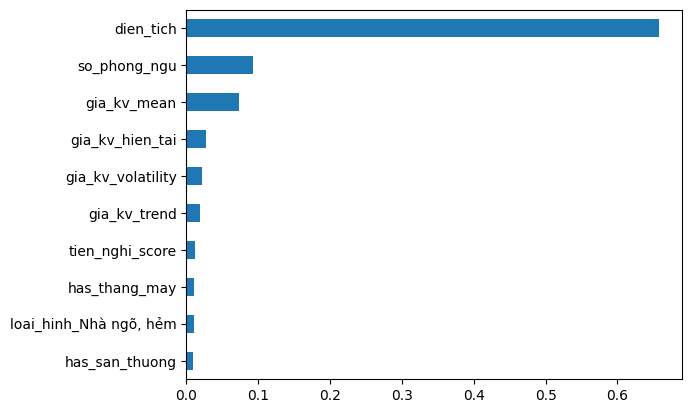

In [17]:
feat_imp.sort_values().tail(10).plot(kind="barh")


### Phân tích Feature Importance

| Feature | Importance | Nhóm |
|---------|-----------|------|
| **dien_tich** | **65.77%** | Quy mô nhà |
| so_phong_ngu | 9.29% | Quy mô nhà |
| gia_kv_mean | 7.27% | Vị trí khu vực |
| gia_kv_hien_tai | 2.68% | Vị trí khu vực |
| gia_kv_volatility | 2.15% | Vị trí khu vực |
| gia_kv_trend | 1.86% | Vị trí khu vực |
| tien_nghi_score | 1.19% | Tiện nghi |
| has_thang_may | 1.01% | Tiện nghi |
| loai_hinh | 1.00% | Loại hình |
| has_san_thuong | 0.97% | Tiện nghi |

**Nhận xét:**
- **Diện tích chiếm 65.77%** → yếu tố quyết định số 1. Model gần như học: giá ≈ đơn giá/m² × diện tích
- **Số phòng ngủ (9.29%)**: Phản ánh quy mô căn nhà, bổ sung cho diện tích
- **Giá khu vực tổng cộng ~14%**: Vị trí ảnh hưởng mạnh đến giá
- **Tiện nghi ~3%**: Thang máy, sân thượng có ảnh hưởng nhưng nhỏ

→ 3 nhóm yếu tố chính: **Quy mô nhà (~75%)** > **Vị trí (~14%)** > **Tiện nghi (~3%)**


## 4. Trực quan hóa Actual vs Predicted


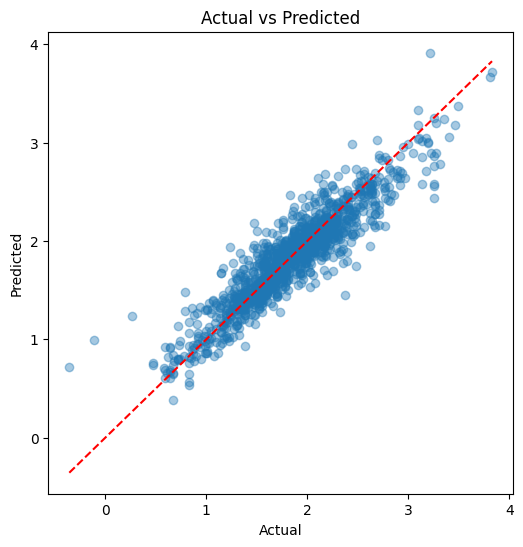

In [18]:
import matplotlib.pyplot as plt

# dự đoán
y_pred = rf_model.predict(X_test)

# vẽ scatter
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

# đường dự đoán hoàn hảo
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


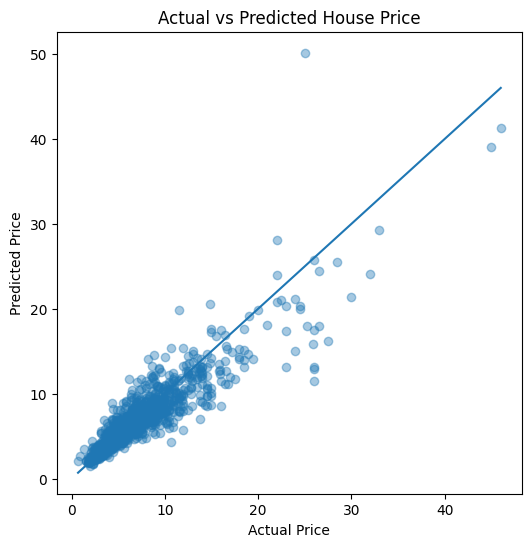

In [19]:
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_test_price, y_pred_price, alpha=0.4)

plt.plot(
    [y_test_price.min(), y_test_price.max()],
    [y_test_price.min(), y_test_price.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.show()


## 5. Lưu mô hình


### Nhận xét
- Biểu đồ Actual vs Predicted cho thấy các điểm tập trung quanh đường chéo (dự đoán hoàn hảo)
- Vùng giá thấp (< 5 tỷ) được dự đoán chính xác hơn
- Vùng giá cao (> 20 tỷ) có sai số lớn hơn — do ít dữ liệu huấn luyện ở phân khúc này


In [20]:
import joblib

joblib.dump(rf_model, "../models/sklearn/rf_model.pkl")


['../models/sklearn/rf_model.pkl']

In [21]:
joblib.dump(X_train.columns, "../models/sklearn/rf_model_features.pkl")


['../models/sklearn/rf_model_features.pkl']

## Kết Luận Tổng Hợp

### Hiệu năng mô hình

| Mô hình | MAE_log | RMSE_log | R² | MAE_tỷ | RMSE_tỷ |
|---------|---------|----------|------|--------|--------|
| **Random Forest** | **0.140** | **0.197** | **0.846** | **1.076** | **1.908** |
| Gradient Boosting | 0.158 | 0.209 | 0.826 | 1.186 | 1.892 |
| Linear Regression | 0.187 | 0.258 | 0.734 | 1.540 | 5.591 |
| Ridge | 0.188 | 0.258 | 0.734 | 1.541 | 5.612 |

### Tại sao Random Forest thắng?
1. **R² = 84.6%** → Giải thích được 84.6% biến thiên giá nhà
2. **MAE = 1.076 tỷ** → Sai số trung bình chỉ ~1.08 tỷ VNĐ
3. **RMSE = 1.908 tỷ** → Thấp hơn nhiều so với Linear (5.59 tỷ)
4. Xử lý tốt quan hệ phi tuyến giữa features
5. Kháng overfitting tốt hơn Decision Tree đơn

### Top 5 yếu tố quan trọng nhất

| Feature | Importance | Giải thích |
|---------|-----------|----------|
| **dien_tich** | **65.77%** | Diện tích = yếu tố quyết định chính |
| so_phong_ngu | 9.29% | Quy mô căn nhà |
| gia_kv_mean | 7.27% | Giá trung bình khu vực |
| gia_kv_hien_tai | 2.68% | Giá hiện tại thị trường |
| gia_kv_volatility | 2.15% | Độ biến động giá |

### Insights kinh doanh
- **"Diện tích là vua"**: 65.77% importance → giá ≈ đơn giá/m² × diện tích
- **Vị trí vẫn quan trọng**: ~14% tổng importance từ giá khu vực
- **Tiện nghi là điểm cộng**: Thang máy, sân thượng chỉ ~3% nhưng tạo giá trị gia tăng

### Đánh giá chất lượng

| Tiêu chí | Kết quả | Đánh giá |
|----------|---------|----------|
| R² | 0.846 | Tốt (>0.8) |
| MAE_tỷ | 1.076 | Sai số ~1.08 tỷ/căn |
| Generalization | Train ≈ Test mean | Tốt |
| Interpretability | Feature importance rõ ràng | Tốt |

### Model được chọn: **Random Forest** (R² = 0.846, MAE = 1.076 tỷ)
Được lưu tại  và sử dụng cho bài toán Anomaly Detection.
